# Track some people

In [8]:
import torch
import torch.nn as nn
import os
from pathlib import Path

# ------------ Blocks --------------
class RC_Layer(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.mu = nn.Parameter(torch.zeros(1, channels, 1, 1))
        self.sigma = nn.Parameter(torch.ones(1, channels, 1, 1))

    def fast_erf(self, x):
        return torch.tanh(1.702 * x)

    def forward(self, x):
        x_centered = (x - self.mu) / (self.sigma + 1e-5)
        phi = 0.5 * (1 + self.fast_erf(x_centered / 1.4142))
        weight = torch.where(x > self.mu, 1 - phi, phi)
        return x + x * weight

class SERegNetBottleneck(nn.Module):
    def __init__(self, in_c, out_c, stride=1, se_ratio=0.25, group_width=8, use_rc=True, is_last_block=False):
        super().__init__()
        self.use_rc = use_rc and is_last_block and out_c >= 256  

        mid_c = out_c
        groups = mid_c // group_width

        self.conv1 = nn.Conv2d(in_c, mid_c, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(mid_c)
        self.relu1 = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(mid_c, mid_c, kernel_size=3, stride=stride, padding=1,
                               groups=groups, bias=False)
        self.bn2 = nn.BatchNorm2d(mid_c)
        self.relu2 = nn.ReLU(inplace=True)

        self.conv3 = nn.Conv2d(mid_c, out_c, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_c)

        se_c = max(1, int(out_c * se_ratio))
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(out_c, se_c, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(se_c, out_c, kernel_size=1),
            nn.Hardsigmoid(inplace=True)
        )

        if self.use_rc:
            self.rc = RC_Layer(out_c)

        if in_c != out_c or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_c),
            )
        else:
            self.skip = nn.Identity()

        self.relu_out = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.relu1(self.bn1(self.conv1(x)))
        out = self.relu2(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out = out * self.se(out)
        if self.use_rc:
            out = self.rc(out)
        return self.relu_out(out + self.skip(x))

# ------------ Unified Single-Head Model --------------
class BestenSingle(nn.Module): 
    def __init__(
        self,
        num_classes, 
        # Unified layer configuration: (repeats, output_channels, stride)
        layer_config = [(1, 64, 2), (1, 128, 2), (1, 256, 2), (1, 512, 2)],
        se_ratio=0.25, 
        group_width=8,                 
        use_rc=True
    ):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(24),
            nn.ReLU(inplace=True),
        )

        # Generate the unified sequential stages
        self.stages, final_out_c = self._make_stage(
            24, layer_config, se_ratio, group_width, use_rc)
        
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(final_out_c, num_classes)

    def _make_stage(self, in_c, config, se_ratio, group_width, use_rc):
        layers = []
        for repeat, out_c, stride in config:
            for i in range(repeat):
                block_stride = stride if i == 0 else 1
                is_last = (i == repeat - 1)
                layers.append(SERegNetBottleneck(
                    in_c if i == 0 else out_c,
                    out_c,
                    stride=block_stride,
                    se_ratio=se_ratio,
                    group_width=group_width,
                    use_rc=use_rc,
                    is_last_block=is_last
                ))
            in_c = out_c
        return nn.Sequential(*layers), in_c

    def forward(self, x):
        x = self.stem(x)
        x = self.stages(x)
        out = self.fc(self.pool(x).flatten(1))
        return out


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the core datasets
pa_train_df = pd.read_csv('./data/pa-100k/train.csv')
pa_val_df = pd.read_csv('./data/pa-100k/val.csv')
peta_full_df = pd.read_csv('./data/peta/peta.csv')

# Recombine PA-100K to have a full version for the master dataset
pa_full_df = pd.concat([pa_train_df, pa_val_df], ignore_index=True)

# 2. Split PETA (80% Train, 20% Val)
peta_train_df, peta_val_df = train_test_split(peta_full_df, test_size=0.2, random_state=42)

# The validated 33-class schema
SCHEMA_KEYS = [
    # --- ANGLE / VIEWPOINT --- 
    "View_Front", "View_Back", "View_Side",
    
    # --- DEMOGRAPHICS ---
    "Female", "Male", "Age_Child", "Age_Adult", "Age_Senior",
    
    # --- HAIRSTYLES ---
    "Bald", "Short_Hair", "Long_Hair",
    
    # --- ACCESSORIES & CARRYING ---
    "Backpack", "Hat", "Glasses", "Muffler_Scarf", "ShoulderBag", 
    "HandBag", "PlasticBag", "CarryingOther",
    
    # --- UPPER CLOTHING ---
    "ShortSleeve", "LongSleeve", "Tshirt", "Jacket", "LongCoat", 
    "Logo", "Plaid", "Stripe",
    
    # --- LOWER CLOTHING ---
    "Trousers", "Jeans", "Shorts", "Skirt_or_Dress",
    
    # --- FOOTWEAR ---
    "Boots", "Sneakers", "LeatherShoes", "Sandals"
]

unified_schema = {
    "View_Front": ["Front", None], "View_Back": ["Back", None], "View_Side": ["Side", None],
    "Female": ["Female", "personalFemale"], "Male": [None, "personalMale"],          
    
    # --- THE FIXED AGE MAPPING (Using actual PETA column names) ---
    "Age_Child": ["AgeLess18", "personalLess15"], 
    "Age_Adult": [
        "Age18-60", 
        ["personalLess30", "personalLess45", "personalLess60"]
    ], 
    "Age_Senior": ["AgeOver60", "personalLarger60"],
    
    "Bald": [None, "hairBald"], "Short_Hair": [None, "hairShort"], "Long_Hair": [None, "hairLong"],
    "Backpack": ["Backpack", "carryingBackpack"], "Hat": ["Hat", "accessoryHat"],
    "Glasses": ["Glasses", "accessorySunglasses"], "Muffler_Scarf": [None, "accessoryMuffler"],
    "ShoulderBag": ["ShoulderBag", "carryingMessengerBag"], "HandBag": ["HandBag", None], 
    "PlasticBag": [None, "carryingPlasticBags"], "CarryingOther": ["HoldObjectsInFront", "carryingOther"],
    "ShortSleeve": ["ShortSleeve", "upperBodyShortSleeve"], "LongSleeve": ["LongSleeve", "upperBodyLongSleeve"],
    "Tshirt": [None, "upperBodyTshirt"], "Jacket": [None, "upperBodyJacket"],
    "LongCoat": ["LongCoat", None], "Logo": ["UpperLogo", "upperBodyLogo"],
    "Plaid": ["UpperPlaid", "upperBodyPlaid"], "Stripe": ["UpperStride", "upperBodyThinStripes"], 
    "Trousers": ["Trousers", "lowerBodyTrousers"], "Jeans": [None, "lowerBodyJeans"],
    "Shorts": ["Shorts", "lowerBodyShorts"], "Skirt_or_Dress": ["Skirt&Dress", "lowerBodyShortSkirt"],
    "Boots": ["boots", "footwearBoots"], "Sneakers": [None, "footwearSneakers"], 
    "LeatherShoes": [None, "footwearLeatherShoes"], "Sandals": [None, "footwearSandals"]
}

def parse_mapping(row, mapping_entry):
    """Safely extracts and combines single columns or lists of columns for a row."""
    if mapping_entry is None:
        return -1.0
    
    # If it's a single string, extract directly
    if isinstance(mapping_entry, str):
        if mapping_entry in row and not pd.isna(row[mapping_entry]):
            return float(row[mapping_entry])
        return -1.0
        
    # If it's a list of columns (e.g., merging multiple age brackets), sum them up and clip to 1.0
    if isinstance(mapping_entry, list):
        valid_vals = [row[c] for c in mapping_entry if c in row and not pd.isna(row[c])]
        if valid_vals:
            return float(min(1.0, sum(valid_vals)))
            
    return -1.0

def merge_datasets(pa_df, peta_df, output_path):
    records = []
    
    # Process PA-100K (Index 0 in unified_schema lists)
    for _, row in pa_df.iterrows():
        new_row = {'image_path': f"./data/pa-100k/data/{row.iloc[0]}", 'dataset_source': 'pa-100k'}
        
        for u_col, (pa_mapping, _) in unified_schema.items():
            # Special handling if PA-100K lacks a direct Male column but has Female
            if u_col == "Male":
                female_val = row.get("Female", -1.0)
                new_row[u_col] = 1.0 - float(female_val) if female_val in [0.0, 1.0] else -1.0
            else:
                new_row[u_col] = parse_mapping(row, pa_mapping)
                
        records.append(new_row)
        
    # Process PETA (Index 1 in unified_schema lists)
    for _, row in peta_df.iterrows():
        new_row = {'image_path': f"./data/peta/{row['image_path']}", 'dataset_source': 'peta'}
        
        for u_col, (_, peta_mapping) in unified_schema.items():
            new_row[u_col] = parse_mapping(row, peta_mapping)
                
        records.append(new_row)
        
    merged_df = pd.DataFrame(records)
    merged_df.to_csv(output_path, index=False)
    print(f"Saved {output_path} with {len(merged_df)} images.")

# 3. Generate the splits AND the master dataset
print("Building Train Split...")
merge_datasets(pa_train_df, peta_train_df, './data/unified_train.csv')

print("\nBuilding Validation Split...")
merge_datasets(pa_val_df, peta_val_df, './data/unified_val.csv')

print("\nBuilding Master Unified Dataset...")
merge_datasets(pa_full_df, peta_full_df, './data/unified_dataset.csv')

Building Train Split...
Saved ./data/unified_train.csv with 95200 images.

Building Validation Split...
Saved ./data/unified_val.csv with 13800 images.

Building Master Unified Dataset...
Saved ./data/unified_dataset.csv with 109000 images.


In [7]:
import scipy.io as sio
import pandas as pd
import numpy as np

# --- CONFIGURATION ---
MAT_PATH = "./data/pa-100k/annotation.mat"
OUTPUT_CSV = "./data/pa-100k/pa100k.csv"

# --- 1. LOAD MATLAB FILE ---
print(f"Loading {MAT_PATH}...")
mat = sio.loadmat(MAT_PATH)

# Extract attribute names (SciPy nests Matlab cells, so we unwrap them)
attributes = [attr[0][0] for attr in mat['attributes']]

# --- 2. EXTRACT & STACK DATA ---
# Extract labels
train_labels = mat['train_label']
val_labels = mat['val_label']
test_labels = mat['test_label']
all_labels = np.vstack((train_labels, val_labels, test_labels))

# Extract image filenames
train_names = [name[0][0] for name in mat['train_images_name']]
val_names = [name[0][0] for name in mat['val_images_name']]
test_names = [name[0][0] for name in mat['test_images_name']]
all_names = train_names + val_names + test_names

total_images = len(all_names)

# --- 3. CALCULATE DISTRIBUTION ---
stats = []
for i, attr in enumerate(attributes):
    pos_count = int(all_labels[:, i].sum())
    freq = (pos_count / total_images) * 100
    stats.append({
        'Attribute': attr, 
        'Count': pos_count, 
        'Frequency (%)': freq
    })

stats_df = pd.DataFrame(stats).sort_values(by='Frequency (%)', ascending=False)
pd.set_option('display.max_rows', None) 

print(f"\n{'='*50}")
print(f"PA-100K DISTRIBUTION ANALYSIS ({total_images} Total Images)")
print(f"{'='*50}")
print(stats_df.to_string(index=False, float_format="%.2f"))

# --- 4. SAVE TO CSV FOR BASELINE WORKFLOW ---
# Create a DataFrame with the image names as the first column
df_export = pd.DataFrame(all_labels, columns=attributes)
df_export.insert(0, 'image_name', all_names)

df_export.to_csv(OUTPUT_CSV, index=False)
print(f"\nSuccess! Saved parsed data to {OUTPUT_CSV}")

Loading ./data/pa-100k/annotation.mat...

PA-100K DISTRIBUTION ANALYSIS (100000 Total Images)
         Attribute  Count  Frequency (%)
          Age18-60  92844          92.84
          Trousers  71916          71.92
       ShortSleeve  56913          56.91
            Female  45336          45.34
        LongSleeve  43087          43.09
              Back  34785          34.78
             Front  34707          34.71
              Side  30508          30.51
       ShoulderBag  19301          19.30
           Glasses  18662          18.66
           HandBag  18115          18.12
            Shorts  16896          16.90
          Backpack  15926          15.93
         UpperLogo  14835          14.84
       Skirt&Dress  11155          11.15
        UpperPlaid  10917          10.92
         AgeLess18   5687           5.69
       UpperStride   5088           5.09
       UpperSplice   4219           4.22
               Hat   4206           4.21
          LongCoat   3365           3.36
    

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CONFIGURATION ---
PA100K_CSV = "./data/pa100k/pa100k.csv"  # Update with your actual path
PETA_CSV = "./data/peta/peta.csv"        # Update with your actual path

unified_schema = {
    # --- ANGLE / VIEWPOINT --- 
    "View_Front": ["Front", None],
    "View_Back":  ["Back", None],
    "View_Side":  ["Side", None],
    
    # --- DEMOGRAPHICS ---
    "Female": ["Female", "personalFemale"],
    "Male": [None, "personalMale"],           
    "Age_Child": ["AgeLess18", "personalLess15"], 
    "Age_YoungAdult": [None, "personalLess30"],
    "Age_Adult": ["Age18-60", "personalLess45"],  
    "Age_Senior": ["AgeOver60", "personalLarger60"],
    
    # --- HAIRSTYLES ---
    "Bald": [None, "hairBald"],
    "Short_Hair": [None, "hairShort"],
    "Long_Hair": [None, "hairLong"],
    
    # --- ACCESSORIES & CARRYING ---
    "Backpack": ["Backpack", "carryingBackpack"],
    "Hat": ["Hat", "accessoryHat"],
    "Glasses": ["Glasses", "accessorySunglasses"],
    "Muffler_Scarf": [None, "accessoryMuffler"],
    "ShoulderBag": ["ShoulderBag", "carryingMessengerBag"], 
    "HandBag": ["HandBag", None], 
    "PlasticBag": [None, "carryingPlasticBags"], 
    "CarryingOther": ["HoldObjectsInFront", "carryingOther"],
    
    # --- UPPER CLOTHING ---
    "ShortSleeve": ["ShortSleeve", "upperBodyShortSleeve"],
    "LongSleeve": ["LongSleeve", "upperBodyLongSleeve"],
    "Tshirt": [None, "upperBodyTshirt"],
    "Jacket": [None, "upperBodyJacket"],
    "LongCoat": ["LongCoat", None],
    "Logo": ["UpperLogo", "upperBodyLogo"],
    "Plaid": ["UpperPlaid", "upperBodyPlaid"],
    "Stripe": ["UpperStride", "upperBodyThinStripes"], 
    
    # --- LOWER CLOTHING ---
    "Trousers": ["Trousers", "lowerBodyTrousers"],
    "Jeans": [None, "lowerBodyJeans"],
    "Shorts": ["Shorts", "lowerBodyShorts"],
    "Skirt_or_Dress": ["Skirt&Dress", "lowerBodyShortSkirt"],
    
    # --- FOOTWEAR ---
    "Boots": ["boots", "footwearBoots"],
    "Sneakers": [None, "footwearSneakers"], 
    "LeatherShoes": [None, "footwearLeatherShoes"],
    "Sandals": [None, "footwearSandals"]
}

# --- 2. LOAD & ANALYZE DATA ---
pa_df = pd.read_csv(PA100K_CSV)
peta_df = pd.read_csv(PETA_CSV)

stats = []

for class_name, (pa_col, peta_col) in unified_schema.items():
    pa_pos = int(pa_df[pa_col].sum()) if pa_col and pa_col in pa_df.columns else 0
    pa_total = len(pa_df) if pa_col and pa_col in pa_df.columns else 0
    
    peta_pos = int(peta_df[peta_col].sum()) if peta_col and peta_col in peta_df.columns else 0
    peta_total = len(peta_df) if peta_col and peta_col in peta_df.columns else 0
    
    total_pos = pa_pos + peta_pos
    total_samples = pa_total + peta_total
    pos_ratio = (total_pos / total_samples) * 100 if total_samples > 0 else 0
    
    stats.append({
        'Attribute': class_name,
        'PA-100K Pos': pa_pos,
        'PETA Pos': peta_pos,
        'Total Pos': total_pos,
        'Frequency (%)': pos_ratio
    })

# --- 3. FORMAT & PRINT RESULTS ---
stats_df = pd.DataFrame(stats).sort_values(by='Frequency (%)', ascending=False)
print(f"{'='*65}\nDATASET DISTRIBUTION ANALYSIS (Combined)\n{'='*65}")
print(stats_df.to_string(index=False, float_format="%.2f"))

# --- 4. VISUALIZE LONG-TAIL DISTRIBUTION ---
plt.figure(figsize=(14, 8))
bars = plt.bar(stats_df['Attribute'], stats_df['Frequency (%)'], color='skyblue')
plt.axhline(y=5, color='orange', linestyle='--', label='5% Warning Threshold')
plt.axhline(y=1, color='red', linestyle='--', label='1% Drop Threshold')
plt.xticks(rotation=90)
plt.ylabel('Positive Frequency (%)')
plt.title('Attribute Distribution Across PA-100K & PETA')
plt.legend()
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: './data/pa100k/pa100k.csv'

In [5]:
import pandas as pd

# --- CONFIGURATION ---
PA100K_CSV = "./data/pa100k/pa100k.csv"
PETA_CSV = "./data/peta/peta.csv"
IGNORE_COLS = ['image_name', 'image', 'id', 'split', 'subset']

def get_distribution(csv_path, dataset_name):
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        return f"Error: Could not find {csv_path}"
    
    total_images = len(df)
    stats = []
    
    for col in df.columns:
        if col not in IGNORE_COLS and pd.api.types.is_numeric_dtype(df[col]):
            pos_count = int(df[col].sum())
            freq = (pos_count / total_images) * 100
            stats.append({
                'Attribute': col, 
                'Count': pos_count, 
                'Frequency (%)': freq
            })
            
    stats_df = pd.DataFrame(stats).sort_values(by='Frequency (%)', ascending=False)
    
    output = f"\n{'='*55}\n"
    output += f"--- {dataset_name} DISTRIBUTION ANALYSIS ({total_images} Total Images) ---\n"
    output += f"{'='*55}\n"
    output += stats_df.to_string(index=False, float_format="%.2f")
    return output

# Force Pandas to render all rows when converting to string
pd.set_option('display.max_rows', None)

# Run and print both
print(get_distribution(PA100K_CSV, "PA-100K"))
print(get_distribution(PETA_CSV, "PETA"))

Error: Could not find ./data/pa100k/pa100k.csv

--- PETA DISTRIBUTION ANALYSIS (19000 Total Images) ---
            Attribute  Count  Frequency (%)
      lowerBodyCasual  16356          86.08
      upperBodyCasual  16207          85.30
  upperBodyLongSleeve  15869          83.52
     accessoryNothing  14238          74.94
            hairShort  14060          74.00
            hairBlack  11491          60.48
        footwearBlack  10668          56.15
         personalMale  10421          54.85
    lowerBodyTrousers   9787          51.51
       personalLess30   9443          49.70
       lowerBodyBlack   9158          48.20
       upperBodyOther   8656          45.56
       personalFemale   8578          45.15
       upperBodyBlack   8532          44.91
        footwearShoes   6902          36.33
       personalLess45   6247          32.88
       lowerBodyJeans   5815          30.61
 footwearLeatherShoes   5628          29.62
 carryingMessengerBag   5619          29.57
      carryingNo

In [6]:
import pandas as pd
import numpy as np

# 1. The Finalized 20-Attribute Schema
unified_schema = {
    # --- DEMOGRAPHICS ---
    "Female": ["Female", "personalFemale"],
    "Age_Child": ["AgeLess18", "personalLess15"], 
    "Age_Over_60": ["AgeOver60", "personalLarger60"], 
    
    # --- HAIRSTYLES (PETA Exclusives) ---
    "Bald": [None, "hairBald"],
    "Short_Hair": [None, "hairShort"],
    "Long_Hair": [None, "hairLong"],
    
    # --- ACCESSORIES & LUGGAGE ---
    "Backpack": ["Backpack", "carryingBackpack"],
    "Hat": ["Hat", "accessoryHat"],
    "Glasses": ["Glasses", "accessorySunglasses"],
    "Handbag": ["HandBag", None], 
    "MessengerBag": [None, "carryingMessengerBag"], 
    "PlasticBag": [None, "carryingPlasticBags"], 
    
    # --- CLOTHING ---
    "ShortSleeve": ["ShortSleeve", "upperBodyShortSleeve"],
    "LongSleeve": ["LongSleeve", "upperBodyLongSleeve"],
    "Trousers": ["Trousers", "lowerBodyTrousers"],
    "Shorts": ["Shorts", "lowerBodyShorts"],
    "Skirt_or_Dress": ["Skirt&Dress", "lowerBodyShortSkirt"],
    
    # --- FOOTWEAR ---
    "Boots": ["boots", "footwearBoots"],
    "Sneakers": [None, "footwearSneaker"], 
    "LeatherShoes": [None, "footwearLeatherShoes"] 
}

# 2. Load the individual DataFrames
pa_df = pd.read_csv('./data/pa-100k/train.csv')
peta_df = pd.read_csv('./data/peta/peta.csv')

unified_records = []

# 3. Process PA-100K Data
print("Mapping PA-100K data (Applying -1 to Hairstyles)...")
for _, row in pa_df.iterrows():
    new_row = {
        'image_path': f"./data/pa-100k/data/{row.iloc[0]}", 
        'dataset_source': 'pa-100k'
    }
    
    for unified_col, (pa_col, _) in unified_schema.items():
        if pa_col and pa_col in pa_df.columns:
            new_row[unified_col] = row[pa_col]
        else:
            new_row[unified_col] = -1.0 # The Ignore Mask
            
    unified_records.append(new_row)

# 4. Process PETA Data
print("Mapping PETA data (Applying -1 to Handbag)...")
for _, row in peta_df.iterrows():
    new_row = {
        'image_path': f"./data/peta/{row['image_path']}", 
        'dataset_source': 'peta'
    }
    
    for unified_col, (_, peta_col) in unified_schema.items():
        if peta_col and peta_col in peta_df.columns:
            new_row[unified_col] = row[peta_col]
        else:
            new_row[unified_col] = -1.0 # The Ignore Mask
            
    unified_records.append(new_row)

# 5. Export the Final Master Dataset
unified_df = pd.DataFrame(unified_records)
output_path = './data/unified_dataset.csv'
unified_df.to_csv(output_path, index=False)

print(f"\n--- MERGE COMPLETE ---")
print(f"Saved master dataset to: {output_path}")
print(f"Total Combined Images: {len(unified_df)}")
print(f"Total Prediction Columns: {len(unified_df.columns) - 2}") # Subtracting path and source

Mapping PA-100K data (Applying -1 to Hairstyles)...
Mapping PETA data (Applying -1 to Handbag)...

--- MERGE COMPLETE ---
Saved master dataset to: ./data/unified_dataset.csv
Total Combined Images: 99000
Total Prediction Columns: 20


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MaskedBCEWithLogitsLoss(nn.Module):
    def __init__(self, pos_weight=None):
        """
        Args:
            pos_weight (Tensor, optional): A weight of positive examples to handle class imbalance.
        """
        super().__init__()
        self.pos_weight = pos_weight

    def forward(self, logits, targets, masks):
        """
        Args:
            logits: The raw, unnormalized predictions from the model [Batch, Attributes]
            targets: The clean labels (0.0 or 1.0) [Batch, Attributes]
            masks: The binary mask indicating valid data (0.0 or 1.0) [Batch, Attributes]
        """
        # 1. Calculate the raw loss for every element. 
        # reduction='none' is crucial here! It prevents PyTorch from automatically averaging the loss.
        raw_loss = F.binary_cross_entropy_with_logits(
            logits, 
            targets, 
            pos_weight=self.pos_weight, 
            reduction='none'
        )
        
        # 2. Apply the mask (The Forcefield)
        # Any label that was originally -1 will have a mask of 0, neutralizing its loss to exactly 0.0
        masked_loss = raw_loss * masks
        
        # 3. Calculate the valid average
        # We sum up the remaining loss and divide ONLY by the number of valid (unmasked) data points.
        valid_entries = masks.sum()
        
        # Add epsilon to prevent NaN errors (division by zero)
        epsilon = 1e-8
        
        final_loss = masked_loss.sum() / (valid_entries + epsilon)
        
        return final_loss

# --- Quick Sanity Check ---
if __name__ == "__main__":
    # Simulate a batch of 2 images with 3 attributes
    dummy_logits = torch.randn(2, 3) 
    dummy_targets = torch.tensor([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]])
    
    # Image 1 has all valid labels. Image 2 is missing the third label (masked with 0).
    dummy_masks = torch.tensor([[1.0, 1.0, 1.0], [1.0, 1.0, 0.0]])
    
    criterion = MaskedBCEWithLogitsLoss()
    loss = criterion(dummy_logits, dummy_targets, dummy_masks)
    
    print(f"Calculated Masked Loss: {loss.item():.4f}")

Calculated Masked Loss: 0.8155


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import SGD
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
import cv2
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import time
import json

# --- 1. Transforms ---
def get_train_transforms():
    return T.Compose([
        T.RandomHorizontalFlip(p=0.5), # Natively handles the PIL Image
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

def get_val_transforms():
    return T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# --- 2. Clean PIL Dataset Class ---
class UnifiedPedestrianDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.df = pd.read_csv(csv_file)
        self.transform = transform
        self.image_paths = self.df['image_path'].values
        self.attributes = self.df.iloc[:, 2:].values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        
        try:
            # Native PIL decoding
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            # Fallback for corrupted images
            image = Image.new('RGB', (128, 256), (0, 0, 0))
            
        # Apply torchvision transforms (including the horizontal flip)
        if self.transform:
            image = self.transform(image)
            
        raw_labels = self.attributes[idx]
        mask = (raw_labels != -1.0).astype(np.float32)
        clean_labels = np.where(raw_labels == -1.0, 0.0, raw_labels)
        
        return image, torch.tensor(clean_labels), torch.tensor(mask)
    
    
# --- 3. Masked Loss & Metrics ---
class MaskedBCEWithLogitsLoss(nn.Module):
    def __init__(self, pos_weight=None):
        super().__init__()
        self.pos_weight = pos_weight

    def forward(self, logits, targets, masks):
        raw_loss = F.binary_cross_entropy_with_logits(logits, targets, pos_weight=self.pos_weight, reduction='none')
        masked_loss = raw_loss * masks
        valid_entries = masks.sum() + 1e-8
        return masked_loss.sum() / valid_entries

def calculate_masked_metrics(logits, targets, masks, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    
    valid_preds = preds * masks
    valid_targets = targets * masks
    
    true_positives = ((valid_preds == 1.0) & (valid_targets == 1.0) & (masks == 1.0)).sum(dim=0)
    false_positives = ((valid_preds == 1.0) & (valid_targets == 0.0) & (masks == 1.0)).sum(dim=0)
    false_negatives = ((valid_preds == 0.0) & (valid_targets == 1.0) & (masks == 1.0)).sum(dim=0)
    
    epsilon = 1e-8
    precision = true_positives / (true_positives + false_positives + epsilon)
    recall = true_positives / (true_positives + false_negatives + epsilon)
    f1_score = 2 * (precision * recall) / (precision + recall + epsilon)
    
    return {'precision': precision.mean().item(), 'recall': recall.mean().item(), 'f1': f1_score.mean().item()}

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_logits, all_targets, all_masks = [], [], []
    
    with torch.no_grad():
        for images, labels, masks in dataloader:
            images, labels, masks = images.to(device), labels.to(device), masks.to(device)
            logits = model(images)
            loss = criterion(logits, labels, masks)
            total_loss += loss.item()
            
            all_logits.append(logits.cpu())
            all_targets.append(labels.cpu())
            all_masks.append(masks.cpu())
            
    full_logits = torch.cat(all_logits, dim=0)
    full_targets = torch.cat(all_targets, dim=0)
    full_masks = torch.cat(all_masks, dim=0)
    
    metrics = calculate_masked_metrics(full_logits, full_targets, full_masks)
    return total_loss / len(dataloader), metrics

# --- 4. Visualization Helper ---
schema_keys = [
    "Female", "Age_Child", "Age_Over_60", "Bald", "Short_Hair", "Long_Hair",
    "Backpack", "Hat", "Glasses", "Handbag", "MessengerBag", "PlasticBag",
    "ShortSleeve", "LongSleeve", "Trousers", "Shorts", "Skirt_or_Dress",
    "Boots", "Sneakers", "LeatherShoes"
]

def visualize_predictions(model, dataloader, schema_keys, device, num_samples=3):
    model.eval()
    images, labels, masks = next(iter(dataloader))
    images, labels, masks = images[:num_samples].to(device), labels[:num_samples].to(device), masks[:num_samples].to(device)
    
    with torch.no_grad():
        logits = model(images)
        preds = (torch.sigmoid(logits) > 0.5).float()
        
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 6))
    if num_samples == 1: axes = [axes]
        
    for i in range(num_samples):
        img = images[i].cpu()
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = img * std + mean
        img = torch.clamp(img, 0, 1).permute(1, 2, 0)
        
        axes[i].imshow(img)
        axes[i].axis('off')
        
        true_text, pred_text = [], []
        for j in range(len(schema_keys)):
            if masks[i, j] == 1.0: 
                if labels[i, j] == 1.0: true_text.append(schema_keys[j])
                if preds[i, j] == 1.0:  pred_text.append(schema_keys[j])
                    
        title = f"TRUE: {', '.join(true_text)}\n\nPRED: {', '.join(pred_text)}"
        color = 'green' if set(true_text) == set(pred_text) else 'darkred'
        axes[i].set_title(title, fontsize=10, color=color, wrap=True)
        
    plt.tight_layout()
    plt.show()


train_dataset = UnifiedPedestrianDataset("./data/unified_train.csv", transform=get_train_transforms())
val_dataset = UnifiedPedestrianDataset("./data/unified_val.csv", transform=get_val_transforms())

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- INIT TRAINING ON: {device.type.upper()} ---")

# The heavy 15-block architecture
model = BestenSingle(
    num_classes=20, 
    layer_config=[(4, 64, 2), (2, 128, 2), (2, 256, 2), (4, 512, 2), (3, 1024, 2)]
).to(device)

total_epochs = 20

criterion = MaskedBCEWithLogitsLoss()
# AdamW is generally superior for multi-label Transformer/SERegNet architectures
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=total_epochs, eta_min=1e-5)

# Initialize the PyTorch AMP Scaler
scaler = torch.cuda.amp.GradScaler()



# ==========================================
# 2. LOGGING SETUP
# ==========================================
log_name = "par_unified_baseline"
log_dir = Path(f"logs/{log_name}")
log_dir.mkdir(parents=True, exist_ok=True)
log_file = log_dir / f"{log_name}_log.json"
log_data = []
best_f1 = 0.0
os.makedirs('./checkpoints', exist_ok=True)

# ==========================================
# 3. LIVE TRAINING LOOP
# ==========================================
print("="*85)
print(f"Starting Training on {device} | Batch: 128 | Workers: 0 (Windows Safe)")
print("="*85)

for epoch in range(1, total_epochs + 1):
    start_time = time.time()
    
    lr = scheduler.get_last_lr()[0]
    
    # Custom p_mix schedule tracking
    if epoch <= 5: p_mix = 0.1
    elif epoch <= 10: p_mix = 0.2
    elif epoch <= 12: p_mix = 0.3
    elif epoch <= 16: p_mix = 0.3
    elif epoch <= 18: p_mix = 0.3
    elif epoch <= 19: p_mix = 0.2
    else: p_mix = 0

    # --- TRAIN PHASE ---
    model.train()
    train_loss = 0.0
    
    train_pbar = tqdm(train_loader, desc=f"Ep {epoch:02d}/{total_epochs} [Train]", leave=False)
    for images, labels, masks in train_pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()
        
        # 1. Autocast forces the GPU to use fast 16-bit math for the forward pass
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels, masks)
        
        # 2. Scaler handles the 16-bit backward pass safely without gradient underflow
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    # --- VAL PHASE ---
    model.eval()
    val_loss = 0.0
    all_logits, all_targets, all_masks = [], [], []
    
    val_pbar = tqdm(val_loader, desc=f"Ep {epoch:02d}/{total_epochs} [Val]  ", leave=False)
    with torch.no_grad():
        for images, labels, masks in val_pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            
            outputs = model(images)
            loss = criterion(outputs, labels, masks)
            
            val_loss += loss.item()
            all_logits.append(outputs.cpu())
            all_targets.append(labels.cpu())
            all_masks.append(masks.cpu())
            
            val_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    scheduler.step()
    
    # Metrics Calculation
    epoch_duration = time.time() - start_time
    t_loss = train_loss / len(train_loader)
    v_loss = val_loss / len(val_loader)
    
    full_logits = torch.cat(all_logits, dim=0)
    full_targets = torch.cat(all_targets, dim=0)
    full_masks = torch.cat(all_masks, dim=0)
    val_metrics = calculate_masked_metrics(full_logits, full_targets, full_masks)
    
    v_prec = val_metrics['precision'] * 100
    v_rec = val_metrics['recall'] * 100
    v_f1 = val_metrics['f1'] * 100
    
    # JSON Logging
    log_data.append({
        "epoch": epoch, "train_loss": t_loss, "val_loss": v_loss,
        "val_prec": v_prec, "val_rec": v_rec, "val_f1": v_f1, 
        "lr": lr, "p_mix": p_mix
    })
    with open(log_file, "w") as f:
        json.dump(log_data, f, indent=4)
        
    print(f"Ep {epoch:2d}/{total_epochs} | Time: {epoch_duration:.1f}s | LR: {lr:.5f} | p_mix: {p_mix}")
    print(f"Loss -> Train: {t_loss:.3f} | Val: {v_loss:.3f}")
    print(f"Metrics -> Val Prec: {v_prec:.1f}% | Val Rec: {v_rec:.1f}% | Val F1: {v_f1:.1f}%", flush=True)
    
    # Visual Sanity Check
    visualize_predictions(model, val_loader, schema_keys, device, num_samples=3)

    # Save Checkpoint
    if v_f1 > best_f1:
        best_f1 = v_f1
        torch.save(model.state_dict(), f"./checkpoints/besten_single_best.pth")
        print("--> Saved new best checkpoint!\n")
    else:
        print("\n")

print("Training cycle complete.")

C:\Users\Delic\AppData\Local\Temp\ipykernel_12064\2671750121.py:185: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


--- INIT TRAINING ON: CUDA ---
Starting Training on cuda | Batch: 128 | Workers: 0 (Windows Safe)


Ep 01/20 [Train]:   0%|          | 0/744 [00:00<?, ?it/s]C:\Users\Delic\AppData\Local\Temp\ipykernel_12064\2671750121.py:234: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


ValueError: Target size (torch.Size([128, 35])) must be the same as input size (torch.Size([128, 20]))

In [22]:
import time
import torch
import psutil
import subprocess
import statistics

def get_gpu_telemetry():
    """Queries NVIDIA drivers directly for GPU utilization and VRAM usage."""
    try:
        util = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=utilization.gpu', '--format=csv,noheader,nounits'], 
            encoding='utf-8'
        )
        mem = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=memory.used', '--format=csv,noheader,nounits'], 
            encoding='utf-8'
        )
        return float(util.strip()), float(mem.strip())
    except:
        return 0.0, 0.0

def run_hardware_telemetry(model, dataloader, criterion, optimizer, device, num_batches=10):
    print(f"\n{'='*70}")
    print(f"--- HARDWARE TELEMETRY DIAGNOSTIC ({num_batches} BATCHES) ---")
    print(f"{'='*70}")
    
    model.train()
    iterator = iter(dataloader)
    
    # Warmup and baseline setup
    _ = next(iterator)
    _ = psutil.cpu_percent(interval=None, percpu=True) # Reset CPU counters
    
    times = {'data_load': 0.0, 'compute': 0.0}
    cpu_loads = []
    gpu_utils = []
    
    for i in range(num_batches):
        # 1. Measure Data Loading (CPU Heavy)
        t0 = time.time()
        images, labels, masks = next(iterator)
        torch.cuda.synchronize()
        times['data_load'] += (time.time() - t0)
        
        # 2. Measure Compute (GPU Heavy)
        t1 = time.time()
        images, labels, masks = images.to(device), labels.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels, masks)
        loss.backward()
        optimizer.step()
        torch.cuda.synchronize()
        times['compute'] += (time.time() - t1)
        
        # 3. Snapshot Hardware States
        cpu_loads.append(psutil.cpu_percent(interval=None, percpu=True))
        gpu_util, _ = get_gpu_telemetry()
        gpu_utils.append(gpu_util)

    # --- Data Processing ---
    avg_load = times['data_load'] / num_batches
    avg_compute = times['compute'] / num_batches
    total_batch_time = avg_load + avg_compute
    
    # Average out the CPU cores across all sampled batches
    num_cores = len(cpu_loads[0])
    avg_cpu_cores = [statistics.mean([batch[core] for batch in cpu_loads]) for core in range(num_cores)]
    avg_gpu_util = statistics.mean(gpu_utils)
    _, vram_used = get_gpu_telemetry()
    
    print(f"\n[TIMING BREAKDOWN]")
    print(f"Total Time Per Batch : {total_batch_time:.4f}s")
    print(f"-> Data Loading      : {avg_load:.4f}s ({(avg_load/total_batch_time)*100:.1f}%)")
    print(f"-> Forward/Backward  : {avg_compute:.4f}s ({(avg_compute/total_batch_time)*100:.1f}%)")
    
    print(f"\n[HARDWARE UTILIZATION]")
    print(f"GPU Utilization      : {avg_gpu_util:.1f}%")
    print(f"GPU VRAM Allocated   : {vram_used:.0f} MB")
    
    print(f"\n[CPU CORE MAP ({num_cores} Logical Cores)]")
    # Print a visual map of CPU cores being used
    for i, core_load in enumerate(avg_cpu_cores):
        bar = "█" * int(core_load / 5) # Visual bar
        print(f"Core {i:02d}: {core_load:5.1f}% | {bar}")

    print("=" * 70)

# Run the test
run_hardware_telemetry(model, train_loader, criterion, optimizer, device, num_batches=10)


--- HARDWARE TELEMETRY DIAGNOSTIC (10 BATCHES) ---

[TIMING BREAKDOWN]
Total Time Per Batch : 2.0419s
-> Data Loading      : 0.2087s (10.2%)
-> Forward/Backward  : 1.8332s (89.8%)

[HARDWARE UTILIZATION]
GPU Utilization      : 95.8%
GPU VRAM Allocated   : 6480 MB

[CPU CORE MAP (8 Logical Cores)]
Core 00:  31.2% | ██████
Core 01:  16.9% | ███
Core 02:  28.0% | █████
Core 03:  21.0% | ████
Core 04:  31.0% | ██████
Core 05:  36.0% | ███████
Core 06:  42.9% | ████████
Core 07:  52.7% | ██████████


Loading ./checkpoints/baseline_v2_best.pth and evaluating validation set...

--- PER-ATTRIBUTE PERFORMANCE (Optimized Thresholds) ---


,Attribute,F1-Score,Precision,Recall,Support
0,Short_Hair,93.699997,91.500000,96.099998,2829
1,Trousers,91.000000,89.699997,92.400002,9258
2,LongSleeve,88.099998,86.500000,89.699997,7535
3,ShortSleeve,85.099998,81.900002,88.400002,6171
4,Female,80.599998,76.099998,85.699997,6639
5,Long_Hair,80.199997,85.199997,75.699997,874
6,LeatherShoes,78.500000,77.199997,79.900002,1132
7,Age_Over_60,77.300003,95.000000,65.199997,319
8,Shorts,75.599998,72.400002,79.000000,1817
9,PlasticBag,74.000000,92.099998,61.900002,281



Showing 5 failures for 'Handbag' (Threshold: 0.1)...


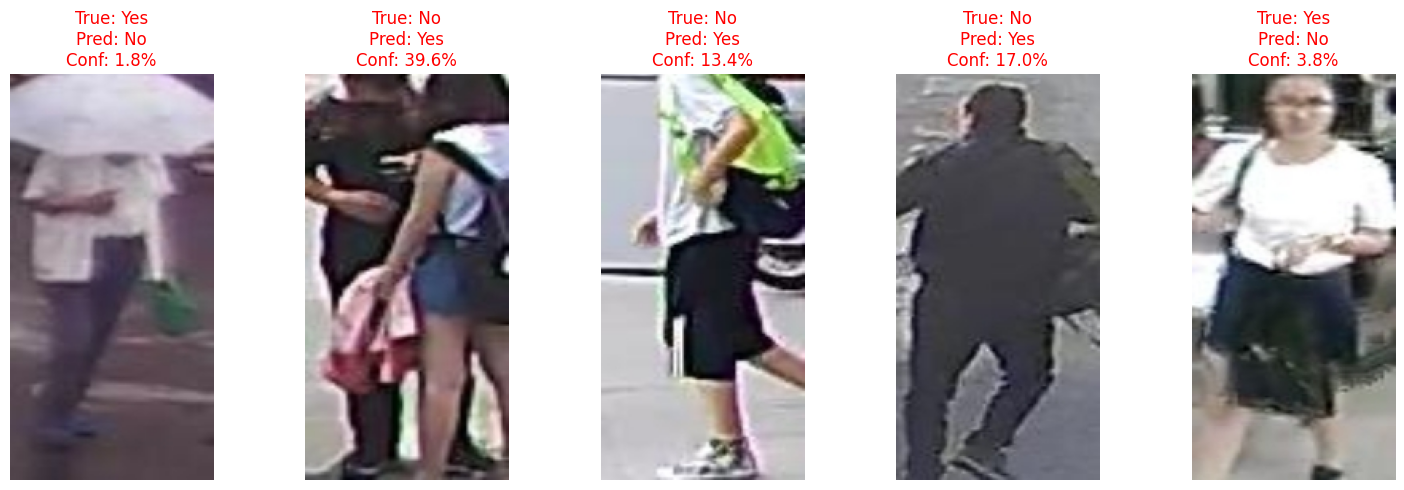

In [13]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms as T
from PIL import Image

# Import your custom modules
from baseline_model import BestenSingle
from dataset import UnifiedPedestrianDataset

# --- 1. CONFIGURATION ---
checkpoint_path = "./checkpoints/baseline_v2_best.pth" 
csv_path = "./data/unified_val.csv"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Injecting the optimal thresholds
OPTIMAL_THRESHOLDS = {
    'Age_Child': 0.10, 'Handbag': 0.10, 'Glasses': 0.15, 'Backpack': 0.15,
    'Bald': 0.20, 'Shorts': 0.25, 'Skirt_or_Dress': 0.25, 'ShortSleeve': 0.25,
    'Female': 0.30, 'PlasticBag': 0.35, 'LeatherShoes': 0.35, 'Age_Over_60': 0.35,
    'MessengerBag': 0.40, 'Boots': 0.40, 'Hat': 0.40, 'Long_Hair': 0.45,
    'Trousers': 0.45, 'Short_Hair': 0.45, 'LongSleeve': 0.50, 'Sneakers': 0.50
}

def get_val_transforms():
    return T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# --- 2. LOAD MODEL & DATA ---
print(f"Loading {checkpoint_path} and evaluating validation set...")
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
schema = checkpoint['schema']

# Updated architecture for baseline_v2
model = BestenSingle(
    num_classes=len(schema), 
    layer_config=[(4, 64, 2), (4, 128, 2), (4, 256, 2), (4, 512, 2), (1, 1024, 2)]
).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

val_dataset = UnifiedPedestrianDataset(csv_path, transform=get_val_transforms())
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0)

# --- 3. RUN INFERENCE ---
all_logits, all_targets, all_masks = [], [], []

with torch.no_grad():
    for images, labels, masks in val_loader:
        outputs = model(images.to(device))
        all_logits.append(outputs.cpu())
        all_targets.append(labels)
        all_masks.append(masks)

logits = torch.cat(all_logits, dim=0)
targets = torch.cat(all_targets, dim=0)
masks = torch.cat(all_masks, dim=0)
probs = torch.sigmoid(logits)

# Apply the custom thresholds dynamically per attribute!
preds = torch.zeros_like(probs)
for i, attr in enumerate(schema):
    thresh = OPTIMAL_THRESHOLDS.get(attr, 0.5)
    preds[:, i] = (probs[:, i] > thresh).float()

# --- 4. PER-ATTRIBUTE METRICS ---
valid_preds = preds * masks
valid_targets = targets * masks

tp = ((valid_preds == 1.0) & (valid_targets == 1.0) & (masks == 1.0)).sum(dim=0)
fp = ((valid_preds == 1.0) & (valid_targets == 0.0) & (masks == 1.0)).sum(dim=0)
fn = ((valid_preds == 0.0) & (valid_targets == 1.0) & (masks == 1.0)).sum(dim=0)

epsilon = 1e-8
precision = tp / (tp + fp + epsilon)
recall = tp / (tp + fn + epsilon)
f1 = 2 * (precision * recall) / (precision + recall + epsilon)
support = tp + fn 

metrics_df = pd.DataFrame({
    'Attribute': schema,
    'F1-Score': (f1 * 100).numpy().round(1),
    'Precision': (precision * 100).numpy().round(1),
    'Recall': (recall * 100).numpy().round(1),
    'Support': support.numpy().astype(int)
}).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print("\n--- PER-ATTRIBUTE PERFORMANCE (Optimized Thresholds) ---")
display(metrics_df)

# --- 5. THE "HUMAN EYE" TEST (VISUALIZER) ---
def visualize_failures(attribute_name, num_images=5):
    """Plots images where the model got a specific attribute wrong."""
    if attribute_name not in schema:
        print(f"Attribute {attribute_name} not found in schema.")
        return
        
    attr_idx = schema.index(attribute_name)
    thresh = OPTIMAL_THRESHOLDS.get(attribute_name, 0.5)
    
    # Find False Positives or False Negatives
    is_wrong = (preds[:, attr_idx] != targets[:, attr_idx]) & (masks[:, attr_idx] == 1.0)
    wrong_indices = torch.where(is_wrong)[0].numpy()
    
    if len(wrong_indices) == 0:
        print(f"No errors found for {attribute_name}!")
        return
        
    print(f"\nShowing {min(num_images, len(wrong_indices))} failures for '{attribute_name}' (Threshold: {thresh})...")
    
    fig, axes = plt.subplots(1, min(num_images, len(wrong_indices)), figsize=(15, 5))
    if num_images == 1: axes = [axes]
    
    # Randomly sample the failures
    np.random.shuffle(wrong_indices)
    
    for i, idx in enumerate(wrong_indices[:num_images]):
        img_path = val_dataset.image_paths[idx]
        img = Image.open(img_path)
        
        ground_truth = "Yes" if targets[idx, attr_idx] == 1.0 else "No"
        prediction = "Yes" if preds[idx, attr_idx] == 1.0 else "No"
        confidence = probs[idx, attr_idx].item() * 100
        
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f"True: {ground_truth}\nPred: {prediction}\nConf: {confidence:.1f}%", 
                          color="red" if ground_truth != prediction else "green")
    
    plt.tight_layout()
    plt.show()

# Test whichever attribute has the lowest F1 score (skipping sneakers if 0 support)
worst_attribute = metrics_df.iloc[-1]['Attribute']
if worst_attribute == "Sneakers": 
    worst_attribute = metrics_df.iloc[-2]['Attribute'] 

visualize_failures(worst_attribute, num_images=5)

In [3]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from tqdm import tqdm

# 1. Imports (Make sure these match your environment)
from baseline_model import BestenSingle
from dataset import UnifiedPedestrianDataset
from torchvision import transforms as T

def get_val_transforms():
    return T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# --- CONFIGURATION ---
CHECKPOINT_PATH = "./checkpoints/baseline_v4_best.pth"  
VAL_CSV = "./data/unified_val.csv"
BATCH_SIZE = 128

SCHEMA_KEYS = [
    "View_Front", "View_Back", "View_Side", "Female", "Male",
    "Age_Child", "Age_Adult", "Age_Senior", "Bald", "Short_Hair", "Long_Hair",
    "Backpack", "Hat", "Glasses", "Muffler_Scarf", "ShoulderBag", 
    "HandBag", "PlasticBag", "CarryingOther", "ShortSleeve", "LongSleeve", 
    "Tshirt", "Jacket", "LongCoat", "Logo", "Plaid", "Stripe",
    "Trousers", "Jeans", "Shorts", "Skirt_or_Dress", "Boots", "Sneakers", 
    "LeatherShoes", "Sandals"
]

def find_optimal_thresholds(y_true, y_probs, schema_keys, masks):
    """
    Grid searches thresholds from 0.01 to 0.99 to find the maximum mA for each class.
    """
    optimal_thresholds = []
    best_mas = []
    
    print(f"\n{'Attribute':<18} | {'Opt Thresh':<10} | {'New mA':<10} | {'Recall':<10} | {'Specificity'}")
    print("-" * 70)
    
    for i, attr in enumerate(schema_keys):
        # Only use valid unmasked samples for this attribute
        valid_idx = np.where(masks[:, i] == 1)[0]
        if len(valid_idx) == 0:
            print(f"{attr:<18} | {'N/A':<10} | {'N/A':<10} | {'N/A':<10} | {'N/A'}")
            optimal_thresholds.append(0.5)
            continue
            
        true_labels = y_true[valid_idx, i]
        probs = y_probs[valid_idx, i]
        
        best_t = 0.5
        best_ma = 0.0
        best_recall = 0.0
        best_spec = 0.0
        
        # Test 99 different thresholds
        for t in np.arange(0.01, 1.00, 0.01):
            preds = (probs >= t).astype(int)
            
            TP = np.sum((true_labels == 1) & (preds == 1))
            FN = np.sum((true_labels == 1) & (preds == 0))
            TN = np.sum((true_labels == 0) & (preds == 0))
            FP = np.sum((true_labels == 0) & (preds == 1))
            
            total_positives = TP + FN
            total_negatives = TN + FP
            
            if total_positives > 0 and total_negatives > 0:
                recall = TP / total_positives
                spec = TN / total_negatives
                mA = (recall + spec) / 2.0
                
                # Keep the threshold that yields the highest mA
                if mA > best_ma:
                    best_ma = mA
                    best_t = t
                    best_recall = recall
                    best_spec = spec
                    
        optimal_thresholds.append(best_t)
        best_mas.append(best_ma)
        
        print(f"{attr:<18} | {best_t:>10.2f} | {best_ma*100:>9.2f}% | {best_recall*100:>9.2f}% | {best_spec*100:>9.2f}%")
        
    print("-" * 70)
    print(f"NEW OPTIMIZED OVERALL mA: {np.mean(best_mas)*100:.2f}%")
    
    return optimal_thresholds

# --- EXECUTION ---
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Loading Attribute Model...")
    
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    layer_config = checkpoint.get('layer_config', [(4, 64, 2), (4, 128, 2), (4, 256, 2), (4, 512, 2), (1, 1024, 2)])
    
    model = BestenSingle(num_classes=len(SCHEMA_KEYS), layer_config=layer_config).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    print("Running inference to collect raw probabilities...")
    val_dataset = UnifiedPedestrianDataset(VAL_CSV, transform=get_val_transforms())
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

    all_probs, all_targets, all_masks = [], [], []

    with torch.no_grad():
        for images, labels, masks in tqdm(val_loader):
            images = images.to(device)
            logits = model(images)
            
            # Use Sigmoid here so we get probabilities (0.0 to 1.0) for thresholding
            probs = torch.sigmoid(logits)
            
            all_probs.append(probs.cpu().numpy())
            all_targets.append(labels.numpy())
            all_masks.append(masks.numpy())

    y_probs_full = np.vstack(all_probs)
    y_true_full = np.vstack(all_targets)
    masks_full = np.vstack(all_masks)

    print("\nSearching for optimal thresholds...")
    best_thresholds = find_optimal_thresholds(y_true_full, y_probs_full, SCHEMA_KEYS, masks_full)
    
    # Print out a Python list you can copy-paste into your tracker
    print("\n--- COPY & PASTE THIS INTO YOUR TRACKER SCRIPT ---")
    print("OPTIMAL_THRESHOLDS = [")
    for i, attr in enumerate(SCHEMA_KEYS):
        print(f"    {best_thresholds[i]:.2f},  # {attr}")
    print("]")

Loading Attribute Model...
Running inference to collect raw probabilities...


100%|██████████| 108/108 [01:37<00:00,  1.11it/s]



Searching for optimal thresholds...

Attribute          | Opt Thresh | New mA     | Recall     | Specificity
----------------------------------------------------------------------
View_Front         |       0.30 |     91.06% |     91.33% |     90.80%
View_Back          |       0.27 |     92.81% |     92.71% |     92.92%
View_Side          |       0.34 |     89.66% |     89.34% |     89.98%
Female             |       0.45 |     88.92% |     89.68% |     88.16%
Male               |       0.55 |     88.92% |     88.16% |     89.68%
Age_Child          |       0.02 |     93.33% |     91.05% |     95.61%
Age_Adult          |       0.96 |     89.96% |     93.95% |     85.97%
Age_Senior         |       0.02 |     90.55% |     86.52% |     94.58%
Bald               |       0.02 |     82.09% |     82.89% |     81.28%
Short_Hair         |       0.80 |     92.57% |     91.73% |     93.41%
Long_Hair          |       0.21 |     93.09% |     93.94% |     92.24%
Backpack           |       0.17 |     

In [23]:
import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from torchvision import transforms as T
from tqdm import tqdm
from dataset import UnifiedPedestrianDataset
from baseline_model import BestenSingle

def get_val_transforms():
    return T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

def evaluate_model(checkpoint_path="./checkpoints/baseline_v4_pruned_50.pth", val_csv="./data/unified_val.csv"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. Load the dataframe to get dataset sources
    val_df = pd.read_csv(val_csv)
    dataset_sources = val_df['dataset_source'].values

    # 2. Load Checkpoint Metadata
    print(f"Loading checkpoint: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    schema = checkpoint['schema']
    layer_config = checkpoint.get('layer_config', [(4, 64, 2), (4, 128, 2), (4, 256, 2), (4, 512, 2), (1, 1024, 2)])
    
    # 3. Initialize Model and Dataset
    model = BestenSingle(num_classes=len(schema), layer_config=layer_config).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    val_dataset = UnifiedPedestrianDataset(val_csv, transform=get_val_transforms())
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4)

    all_preds, all_targets, all_masks = [], [], []

    # 4. Run Inference
    with torch.no_grad():
        for images, labels, masks in tqdm(val_loader, desc="Evaluating"):
            images = images.to(device)
            outputs = model(images)
            
            # Convert logits to binary predictions (Threshold 0.0 before sigmoid = 0.5 after sigmoid)
            preds = (outputs > 0.0).float()
            
            all_preds.append(preds.cpu().numpy())
            all_targets.append(labels.numpy())
            all_masks.append(masks.numpy())

    preds = np.vstack(all_preds)
    targets = np.vstack(all_targets)
    masks = np.vstack(all_masks)

    # 5. Helper Function to Calculate mA Metrics
    def calculate_metrics(p, t, m, subset_name):
        print(f"\n{'='*75}")
        print(f"METRICS FOR: {subset_name.upper()} ({len(p)} images)")
        print(f"{'='*75}")
        
        # Keep Original Instance Accuracy metric for reference
        correct_per_image = ((p == t) * m).sum(axis=1)
        valid_labels_per_image = m.sum(axis=1)
        safe_div = np.where(valid_labels_per_image > 0, valid_labels_per_image, 1)
        instance_acc = (correct_per_image / safe_div)[valid_labels_per_image > 0].mean()
        
        print(f"Overall Instance Accuracy (Correct labels per image): {instance_acc * 100:.2f}%\n")
        
        # Setup mA Table
        print(f"{'Attribute':<18} | {'Pos Acc (Recall)':<18} | {'Neg Acc (Spec)':<18} | {'mA Score'}")
        print("-" * 75)
        
        ma_scores = []
        
        for i, attr in enumerate(schema):
            # Only calculate where mask == 1
            valid_idx = np.where(m[:, i] == 1)[0]
            if len(valid_idx) == 0:
                print(f"{attr:<18} | {'N/A':>16} | {'N/A':>16} | {'N/A':>9}")
                continue
                
            attr_preds = p[valid_idx, i]
            attr_targets = t[valid_idx, i]
            
            # Calculate Intersections
            TP = np.sum((attr_targets == 1) & (attr_preds == 1))
            FN = np.sum((attr_targets == 1) & (attr_preds == 0))
            TN = np.sum((attr_targets == 0) & (attr_preds == 0))
            FP = np.sum((attr_targets == 0) & (attr_preds == 1))
            
            total_positives = TP + FN
            total_negatives = TN + FP
            
            if total_positives > 0 and total_negatives > 0:
                pos_acc = TP / total_positives
                neg_acc = TN / total_negatives
                mA = (pos_acc + neg_acc) / 2.0
                
                ma_scores.append(mA)
                print(f"{attr:<18} | {pos_acc*100:>15.2f}% | {neg_acc*100:>15.2f}% | {mA*100:>8.2f}%")
            else:
                # Catch edge cases where a small val set might not have a single positive example of a rare trait
                print(f"{attr:<18} | {'No Pos/Neg Split':>16} | {'No Pos/Neg Split':>16} | {'N/A':>9}")

        # Calculate Overall mA
        if ma_scores:
            overall_ma = np.mean(ma_scores) * 100
            print("-" * 75)
            print(f"OVERALL BALANCED mA: {overall_ma:.2f}%")
        else:
            print("-" * 75)
            print("OVERALL BALANCED mA: N/A")

    # 6. Global Metrics
    calculate_metrics(preds, targets, masks, "Combined Unified Dataset")

    # 7. Dataset-Specific Metrics
    pa_idx = np.where(dataset_sources == 'pa-100k')[0]
    peta_idx = np.where(dataset_sources == 'peta')[0]

    calculate_metrics(preds[pa_idx], targets[pa_idx], masks[pa_idx], "PA-100K Only")
    calculate_metrics(preds[peta_idx], targets[peta_idx], masks[peta_idx], "PETA Only")

if __name__ == "__main__":
    evaluate_model(checkpoint_path="./checkpoints/baseline_v4_pruned_50.pth")

Loading checkpoint: ./checkpoints/baseline_v4_pruned_50.pth


Evaluating: 100%|██████████| 108/108 [00:57<00:00,  1.89it/s]


METRICS FOR: COMBINED UNIFIED DATASET (13800 images)
Overall Instance Accuracy (Correct labels per image): 92.67%

Attribute          | Pos Acc (Recall)   | Neg Acc (Spec)     | mA Score
---------------------------------------------------------------------------
View_Front         |           86.53% |           93.71% |    90.12%
View_Back          |           84.53% |           96.81% |    90.67%
View_Side          |           86.27% |           91.71% |    88.99%
Female             |           90.54% |           85.95% |    88.25%
Male               |           85.95% |           90.54% |    88.25%
Age_Child          |           45.76% |           99.74% |    72.75%
Age_Adult          |           99.49% |           49.12% |    74.30%
Age_Senior         |           65.83% |           99.84% |    82.83%
Bald               |           22.37% |          100.00% |    61.18%
Short_Hair         |           94.77% |           85.79% |    90.28%
Long_Hair          |           87.64% |       

In [24]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from tqdm import tqdm

# 1. Imports (Make sure these match your environment)
from baseline_model import BestenSingle
from dataset import UnifiedPedestrianDataset
from torchvision import transforms as T

def get_val_transforms():
    return T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# --- CONFIGURATION ---
CHECKPOINT_PATH = "./checkpoints/baseline_v4_pruned_50.pth"  
VAL_CSV = "./data/unified_val.csv"
BATCH_SIZE = 128

SCHEMA_KEYS = [
    "View_Front", "View_Back", "View_Side", "Female", "Male",
    "Age_Child", "Age_Adult", "Age_Senior", "Bald", "Short_Hair", "Long_Hair",
    "Backpack", "Hat", "Glasses", "Muffler_Scarf", "ShoulderBag", 
    "HandBag", "PlasticBag", "CarryingOther", "ShortSleeve", "LongSleeve", 
    "Tshirt", "Jacket", "LongCoat", "Logo", "Plaid", "Stripe",
    "Trousers", "Jeans", "Shorts", "Skirt_or_Dress", "Boots", "Sneakers", 
    "LeatherShoes", "Sandals"
]

def find_optimal_thresholds(y_true, y_probs, schema_keys, masks):
    """
    Grid searches thresholds from 0.01 to 0.99 to find the maximum mA for each class.
    """
    optimal_thresholds = []
    best_mas = []
    
    print(f"\n{'Attribute':<18} | {'Opt Thresh':<10} | {'New mA':<10} | {'Recall':<10} | {'Specificity'}")
    print("-" * 70)
    
    for i, attr in enumerate(schema_keys):
        # Only use valid unmasked samples for this attribute
        valid_idx = np.where(masks[:, i] == 1)[0]
        if len(valid_idx) == 0:
            print(f"{attr:<18} | {'N/A':<10} | {'N/A':<10} | {'N/A':<10} | {'N/A'}")
            optimal_thresholds.append(0.5)
            continue
            
        true_labels = y_true[valid_idx, i]
        probs = y_probs[valid_idx, i]
        
        best_t = 0.5
        best_ma = 0.0
        best_recall = 0.0
        best_spec = 0.0
        
        # Test 99 different thresholds
        for t in np.arange(0.01, 1.00, 0.01):
            preds = (probs >= t).astype(int)
            
            TP = np.sum((true_labels == 1) & (preds == 1))
            FN = np.sum((true_labels == 1) & (preds == 0))
            TN = np.sum((true_labels == 0) & (preds == 0))
            FP = np.sum((true_labels == 0) & (preds == 1))
            
            total_positives = TP + FN
            total_negatives = TN + FP
            
            if total_positives > 0 and total_negatives > 0:
                recall = TP / total_positives
                spec = TN / total_negatives
                mA = (recall + spec) / 2.0
                
                # Keep the threshold that yields the highest mA
                if mA > best_ma:
                    best_ma = mA
                    best_t = t
                    best_recall = recall
                    best_spec = spec
                    
        optimal_thresholds.append(best_t)
        best_mas.append(best_ma)
        
        print(f"{attr:<18} | {best_t:>10.2f} | {best_ma*100:>9.2f}% | {best_recall*100:>9.2f}% | {best_spec*100:>9.2f}%")
        
    print("-" * 70)
    print(f"NEW OPTIMIZED OVERALL mA: {np.mean(best_mas)*100:.2f}%")
    
    return optimal_thresholds

# --- EXECUTION ---
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Loading Attribute Model...")
    
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    layer_config = checkpoint.get('layer_config', [(4, 64, 2), (4, 128, 2), (4, 256, 2), (4, 512, 2), (1, 1024, 2)])
    
    model = BestenSingle(num_classes=len(SCHEMA_KEYS), layer_config=layer_config).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    print("Running inference to collect raw probabilities...")
    val_dataset = UnifiedPedestrianDataset(VAL_CSV, transform=get_val_transforms())
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

    all_probs, all_targets, all_masks = [], [], []

    with torch.no_grad():
        for images, labels, masks in tqdm(val_loader):
            images = images.to(device)
            logits = model(images)
            
            # Use Sigmoid here so we get probabilities (0.0 to 1.0) for thresholding
            probs = torch.sigmoid(logits)
            
            all_probs.append(probs.cpu().numpy())
            all_targets.append(labels.numpy())
            all_masks.append(masks.numpy())

    y_probs_full = np.vstack(all_probs)
    y_true_full = np.vstack(all_targets)
    masks_full = np.vstack(all_masks)

    print("\nSearching for optimal thresholds...")
    best_thresholds = find_optimal_thresholds(y_true_full, y_probs_full, SCHEMA_KEYS, masks_full)
    
    # Print out a Python list you can copy-paste into your tracker
    print("\n--- COPY & PASTE THIS INTO YOUR TRACKER SCRIPT ---")
    print("OPTIMAL_THRESHOLDS = [")
    for i, attr in enumerate(SCHEMA_KEYS):
        print(f"    {best_thresholds[i]:.2f},  # {attr}")
    print("]")

Loading Attribute Model...
Running inference to collect raw probabilities...


100%|██████████| 108/108 [00:52<00:00,  2.08it/s]



Searching for optimal thresholds...

Attribute          | Opt Thresh | New mA     | Recall     | Specificity
----------------------------------------------------------------------
View_Front         |       0.37 |     90.70% |     90.27% |     91.13%
View_Back          |       0.22 |     92.17% |     91.26% |     93.09%
View_Side          |       0.41 |     89.38% |     89.16% |     89.60%
Female             |       0.57 |     88.41% |     88.91% |     87.91%
Male               |       0.43 |     88.41% |     87.91% |     88.91%
Age_Child          |       0.03 |     93.07% |     90.92% |     95.22%
Age_Adult          |       0.95 |     89.15% |     89.78% |     88.51%
Age_Senior         |       0.03 |     89.15% |     84.95% |     93.34%
Bald               |       0.03 |     81.35% |     82.89% |     79.81%
Short_Hair         |       0.63 |     91.56% |     92.19% |     90.94%
Long_Hair          |       0.31 |     92.40% |     93.82% |     90.98%
Backpack           |       0.31 |     

## MOT20

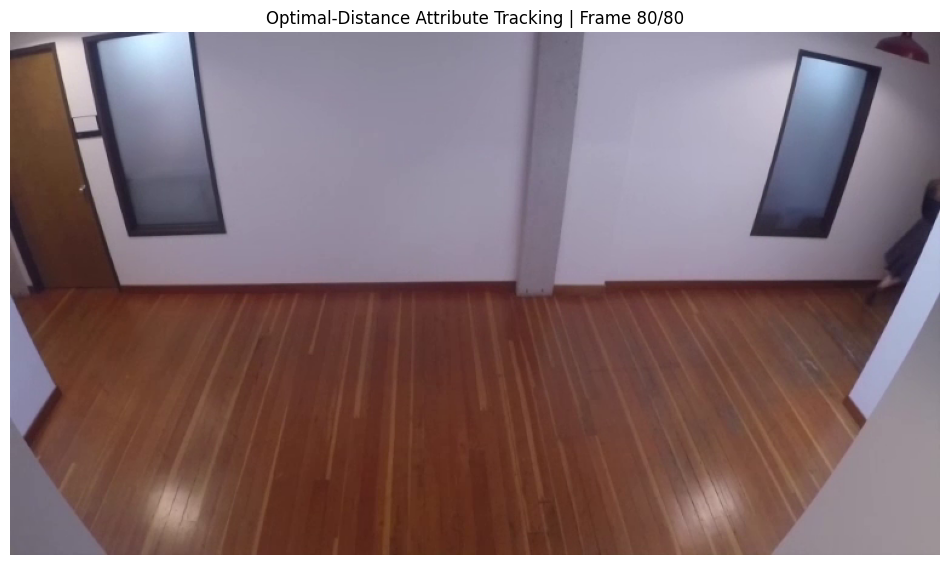

video 1/1 (frame 81/596) c:\Coding\Tracking\test_video.mp4: 384x640 (no detections), 26.9ms
E2E Stream Complete!


In [37]:
import cv2
import torch
import numpy as np
import torchvision.transforms as T
import matplotlib.pyplot as plt
from IPython.display import clear_output
from ultralytics import YOLO
from collections import defaultdict

# 1. Import your custom baseline architecture
from baseline_model import BestenSingle

# --- CONFIGURATION ---
CHECKPOINT_PATH = "./checkpoints/baseline_v4_best.pth"  # Point to your v4 checkpoint
VIDEO_SOURCE = "test_video.mp4"
TOP_K_OPTIMAL = 5  # Number of optimal distance frames to aggregate

SCHEMA_KEYS = [
    # 0, 1, 2
    "View_Front", "View_Back", "View_Side",
    # 3, 4
    "Female", "Male",
    # 5, 6, 7
    "Age_Child", "Age_Adult", "Age_Senior",
    # 8, 9, 10
    "Bald", "Short_Hair", "Long_Hair",
    # 11 through 35 (Independent Traits)
    "Backpack", "Hat", "Glasses", "Muffler_Scarf", "ShoulderBag", 
    "HandBag", "PlasticBag", "CarryingOther",
    "ShortSleeve", "LongSleeve", "Tshirt", "Jacket", "LongCoat", 
    "Logo", "Plaid", "Stripe",
    "Trousers", "Jeans", "Shorts", "Skirt_or_Dress",
    "Boots", "Sneakers", "LeatherShoes", "Sandals"
]

# 2. Setup Device & Load Attribute Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Loading Attribute Model...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

# Extract custom layer configuration or fall back to default
layer_config = checkpoint.get('layer_config', [(4, 64, 2), (4, 128, 2), (4, 256, 2), (4, 512, 2), (1, 1024, 2)])

attr_model = BestenSingle(num_classes=len(SCHEMA_KEYS), layer_config=layer_config).to(device)
attr_model.load_state_dict(checkpoint['model_state_dict'])
attr_model.eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((256, 128)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Setup YOLO Tracker
yolo_model = YOLO("yolo11n.pt") 

# Buffer structure: track_id -> list of tuples: (quality_score, probs_array)
track_optimal_buffer = defaultdict(list)

results = yolo_model.track(
    source=VIDEO_SOURCE, 
    tracker="bytetrack.yaml", 
    classes=[0], 
    conf=0.4, 
    stream=True
)

MAX_FRAMES = 80 
print("Starting Optimal Distance Inference Stream...")

for frame_idx, r in enumerate(results):
    if frame_idx >= MAX_FRAMES:
        break
        
    frame = r.orig_img.copy()
    current_ids_in_frame = set()
    
    if r.boxes is not None and r.boxes.id is not None:
        boxes = r.boxes.xyxy.cpu().numpy() 
        ids = r.boxes.id.cpu().numpy()     
        
        for box, track_id in zip(boxes, ids):
            track_id = int(track_id)
            current_ids_in_frame.add(track_id)
            x1, y1, x2, y2 = map(int, box)
            
            # Boundary checks
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(frame.shape[1], x2), min(frame.shape[0], y2)
            
            bbox_height = y2 - y1
            bbox_width = x2 - x1
            quality_score = bbox_height * bbox_width  # Resolution / proximity metric
            
            pedestrian_crop = frame[y1:y2, x1:x2]
            
            if pedestrian_crop.size > 0 and bbox_height > 25:
                # --- PREPARE CROP ---
                crop_rgb = cv2.cvtColor(pedestrian_crop, cv2.COLOR_BGR2RGB)
                input_tensor = transform(crop_rgb).unsqueeze(0).to(device)
                
                # --- RUN INFERENCE ---
                with torch.no_grad():
                    logits = attr_model(input_tensor)
                    probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()
                
                # --- UPDATE TOP-K OPTIMAL DISTANCE BUFFER ---
                track_optimal_buffer[track_id].append((quality_score, probs))
                # Sort descending by resolution (optimal closeness) and retain top-5
                track_optimal_buffer[track_id].sort(key=lambda item: item[0], reverse=True)
                if len(track_optimal_buffer[track_id]) > TOP_K_OPTIMAL:
                    track_optimal_buffer[track_id] = track_optimal_buffer[track_id][:TOP_K_OPTIMAL]
                
                # --- COMPUTE ENSEMBLE MEAN OVER TOP-K PREDICTIONS ---
                buffered_probs = [item[1] for item in track_optimal_buffer[track_id]]
                agg_probs = np.mean(buffered_probs, axis=0)
                
                # 1. Standard Demographics
                view_labels = ["Front", "Back", "Side"]
                view_label = f"View: {view_labels[np.argmax(agg_probs[0:3])]}"
                gender_label = "Female" if agg_probs[3] > agg_probs[4] else "Male"
                
                age_labels = ["Age_Child", "Age_Adult", "Age_Senior"]
                age_label = age_labels[np.argmax(agg_probs[5:8])]
                
                hair_labels = ["Bald", "Short_Hair", "Long_Hair"]
                hair_label = hair_labels[np.argmax(agg_probs[8:11])]

                # 2. Strict Thresholding for Noisy Bag Classes (75%+ required)
                bag1_idx = 11 if agg_probs[11] > agg_probs[15] else 15
                bag1 = SCHEMA_KEYS[bag1_idx] if agg_probs[bag1_idx] > 0.75 else None
                
                bag2_indices = [16, 17, 18]
                bag2_idx = bag2_indices[np.argmax([agg_probs[i] for i in bag2_indices])]
                bag2 = SCHEMA_KEYS[bag2_idx] if agg_probs[bag2_idx] > 0.75 else None

                # 3. Priority Override for Upper Body (Specific vs Generic)
                upper = None
                if agg_probs[23] > 0.40:   upper = "LongCoat"
                elif agg_probs[22] > 0.40: upper = "Jacket"
                elif agg_probs[21] > 0.50: upper = "Tshirt"
                # Check patterns before falling back to generic sleeves
                elif agg_probs[24] > 0.60: upper = "Logo"
                elif agg_probs[25] > 0.60: upper = "Plaid"
                elif agg_probs[26] > 0.60: upper = "Stripe"
                # Fallback to generic sleeves
                elif agg_probs[20] > agg_probs[19] and agg_probs[20] > 0.50: upper = "LongSleeve"
                elif agg_probs[19] > 0.50: upper = "ShortSleeve"

                # 4. Standard Argmax for Lower Body & Shoes
                lower_indices = [27, 28, 29, 30]
                lower_idx = lower_indices[np.argmax([agg_probs[i] for i in lower_indices])]
                lower = SCHEMA_KEYS[lower_idx] if agg_probs[lower_idx] > 0.50 else None
                
                shoe_indices = [31, 32, 33, 34]
                shoe_idx = shoe_indices[np.argmax([agg_probs[i] for i in shoe_indices])]
                shoes = SCHEMA_KEYS[shoe_idx] if agg_probs[shoe_idx] > 0.50 else None

                # 5. Independent Accessories
                indep_attrs = [SCHEMA_KEYS[i] for i in [12, 13, 14] if agg_probs[i] > 0.50]

                # --- COMPILE DISPLAY LIST ---
                active_attrs = []
                for item in [bag1, bag2, upper, lower, shoes]:
                    if item is not None:
                        active_attrs.append(item)
                active_attrs.extend(indep_attrs)
                
                display_attrs = [gender_label, view_label, age_label, hair_label] + active_attrs
                
                # --- DRAWING ---
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                
                # Header: ID + Buffered Optimal Sample Count
                buf_count = len(track_optimal_buffer[track_id])
                cv2.putText(frame, f"ID: {track_id} (Opt: {buf_count}/{TOP_K_OPTIMAL})", 
                            (x1, max(20, y1 - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 2)
                
                # Render attributes vertically alongside box
                y_text = y1 + 15
                for attr in display_attrs:
                    cv2.putText(frame, attr, (x2 + 6, y_text), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.48, (0, 255, 255), 2)
                    y_text += 20

    # Cleanup stale tracks
    stale_ids = set(track_optimal_buffer.keys()) - current_ids_in_frame
    for stale_id in stale_ids:
        del track_optimal_buffer[stale_id]

    # --- INLINE JUPYTER DISPLAY ---
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    clear_output(wait=True)
    plt.figure(figsize=(12, 7))
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.title(f"Optimal-Distance Attribute Tracking | Frame {frame_idx + 1}/{MAX_FRAMES}")
    plt.show()

print("E2E Stream Complete!")

## -------------------- Essential functions ----------------------

In [6]:
import cv2
import torch
import numpy as np
import torchvision.transforms as T
from ultralytics import YOLO
from collections import defaultdict
import time
from collections import defaultdict, deque

# 1. Import your custom baseline architecture
from baseline_model import BestenSingle

# --- CONFIGURATION & SCHEMA ---
SCHEMA_KEYS = [
    "View_Front", "View_Back", "View_Side",
    "Female", "Male",
    "Age_Child", "Age_Adult", "Age_Senior",
    "Bald", "Short_Hair", "Long_Hair",
    "Backpack", "Hat", "Glasses", "Muffler_Scarf", "ShoulderBag", 
    "HandBag", "PlasticBag", "CarryingOther",
    "ShortSleeve", "LongSleeve", "Tshirt", "Jacket", "LongCoat", 
    "Logo", "Plaid", "Stripe",
    "Trousers", "Jeans", "Shorts", "Skirt_or_Dress",
    "Boots", "Sneakers", "LeatherShoes", "Sandals"
]

def load_tracking_models(checkpoint_path, device, num_classes=36):
    """Initializes and returns the YOLO tracker, Attribute Model, and image transforms."""
    print("Loading Attribute Model...")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    layer_config = checkpoint.get('layer_config', [(4, 64, 2), (4, 128, 2), (4, 256, 2), (4, 512, 2), (1, 1024, 2)])
    
    attr_model = BestenSingle(num_classes=num_classes, layer_config=layer_config).to(device)
    attr_model.load_state_dict(checkpoint['model_state_dict'])
    attr_model.eval()

    transform = T.Compose([
        T.ToPILImage(),
        T.Resize((256, 128)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    print("Loading YOLO Tracker...")
    yolo_model = YOLO("yolo11n.pt") 
    
    return yolo_model, attr_model, transform

def parse_attributes(agg_probs, schema_keys=SCHEMA_KEYS):
  """Translates raw model probabilities for all 36 schema keys into structured,

  physically consistent pedestrian attributes using priority ladders and tuned
  thresholds.
  """
  detected = []

  # =========================================================
  # 1. VIEWPOINT (Indices 0, 1, 2) - Mutually Exclusive Argmax
  # =========================================================
  view_indices = [0, 1, 2]
  view_names = ["Front", "Back", "Side"]
  best_view_idx = np.argmax([agg_probs[i] for i in view_indices])
  detected.append(f"View: {view_names[best_view_idx]}")

  # =========================================================
  # 2. GENDER (Indices 3, 4) - Mutually Exclusive Argmax
  # =========================================================
  female_p, male_p = agg_probs[3], agg_probs[4]
  detected.append("Female" if female_p > male_p else "Male")

  # =========================================================
  # 3. AGE (Indices 5, 6, 7) - Priority Ladder (Rare Over Generic)
  # =========================================================
  # Child and Senior are rarer, so evaluate them first with lower thresholds
  if agg_probs[5] > 0.40:
    detected.append("Age_Child")
  elif agg_probs[7] > 0.40:
    detected.append("Age_Senior")
  else:
    detected.append("Age_Adult")

  # =========================================================
  # 4. HAIR STYLE (Indices 8, 9, 10) - Priority Ladder
  # =========================================================
  if agg_probs[8] > 0.25:
    detected.append("Bald")
  elif agg_probs[10] > 0.45:
    detected.append("Long_Hair")
  elif agg_probs[9] > 0.45:
    detected.append("Short_Hair")

  # =========================================================
  # 5. UPPER BODY & PATTERNS (Indices 19 - 26) - Specificity Ladder
  # =========================================================
  # Outerwear -> Tops -> Patterns -> Generic Sleeves
  if agg_probs[23] > 0.40:
    detected.append("LongCoat")
  elif agg_probs[22] > 0.20:
    detected.append("Jacket")
  elif agg_probs[21] > 0.20:
    detected.append("Tshirt")
  elif agg_probs[24] > 0.20:
    detected.append("Logo")
  elif agg_probs[25] > 0.50:
    detected.append("Plaid")
  elif agg_probs[26] > 0.50:
    detected.append("Stripe")
  elif agg_probs[20] > agg_probs[19] and agg_probs[20] > 0.50:
    detected.append("LongSleeve")
  elif agg_probs[19] > 0.80:
    detected.append("ShortSleeve")

  # =========================================================
  # 6. LOWER BODY (Indices 27, 28, 29, 30) - Specificity Ladder
  # =========================================================
  # Distinct cuts (Skirt/Dress/Shorts) take precedence over generic pants
  if agg_probs[30] > 0.30:
    detected.append("Skirt_or_Dress")
  elif agg_probs[29] > 0.30:
    detected.append("Shorts")
  elif agg_probs[28] > 0.30:
    detected.append("Jeans")
  elif agg_probs[27] > 0.50:
    detected.append("Trousers")

  # =========================================================
  # 7. FOOTWEAR (Indices 31, 32, 33, 34) - Mutually Exclusive Argmax
  # =========================================================
  shoe_indices = [31, 32, 33, 34]  # Boots, Sneakers, LeatherShoes, Sandals
  best_shoe_idx = shoe_indices[np.argmax([agg_probs[i] for i in shoe_indices])]
  if agg_probs[best_shoe_idx] > 0.45:
    detected.append(schema_keys[best_shoe_idx])

  # =========================================================
  # 8. BAGS & CARRYING (Indices 11, 15, 16, 17, 18) - High Threshold (70%+)
  # =========================================================
  # Back vs Shoulder Bag
  if agg_probs[11] > 0.70 and agg_probs[11] > agg_probs[15]:
    detected.append("Backpack")
  elif agg_probs[15] > 0.70:
    detected.append("ShoulderBag")

  # Hand-held items (HandBag, PlasticBag, CarryingOther)
  hand_indices = [16, 17, 18]
  best_hand_idx = hand_indices[np.argmax([agg_probs[i] for i in hand_indices])]
  if agg_probs[best_hand_idx] > 0.70:
    detected.append(schema_keys[best_hand_idx])

  # =========================================================
  # 9. ACCESSORIES (Indices 12, 13, 14) - Independent Binary Checks
  # =========================================================
  if agg_probs[12] > 0.50:
    detected.append("Hat")
  if agg_probs[13] > 0.15:
    detected.append("Glasses")
  if agg_probs[14] > 0.65:
    detected.append("Muffler_Scarf")

  return detected

# --- NEW: STATE MANAGEMENT CLASS ---
class PedestrianState:
    def __init__(self, top_k=10, fps=30):
        self.top_k = top_k
        self.buffer = []
        self.locked_attrs = []
        self.is_collecting = True
        self.active_view = None
        self.view_history = deque(maxlen=3 * fps) # 3 seconds rolling window

    def update(self, q_score, probs, schema_keys):
        # Determine instantaneous view for this frame
        views = ["Front", "Back", "Side"]
        current_view = views[np.argmax(probs[0:3])]
        self.view_history.append(current_view)

        # 1. Check for angle shifts if we are already locked
        if not self.is_collecting:
            view_counts = defaultdict(int)
            for v in self.view_history:
                view_counts[v] += 1
            
            # If a NEW angle appears at least 5 times in the last 3 seconds
            for v, count in view_counts.items():
                if v != self.active_view and count >= 5:
                    self.is_collecting = True
                    self.buffer = [] # Start fresh buffer for the new angle
                    self.view_history.clear()
                    break
        
        # 2. Manage the optimal inference window
        if self.is_collecting:
            self.buffer.append((q_score, probs))
            self.buffer.sort(key=lambda x: x[0], reverse=True) # Sort by quality score
            if len(self.buffer) > self.top_k:
                self.buffer = self.buffer[:self.top_k]
            
            # If we achieved the optimal window lock
            if len(self.buffer) == self.top_k:
                agg_probs = np.mean([p for _, p in self.buffer], axis=0)
                self.locked_attrs = parse_attributes(agg_probs, schema_keys)
                self.active_view = views[np.argmax(agg_probs[0:3])]
                self.is_collecting = False
                self.view_history.clear() # Reset to prevent immediate re-trigger

        # 3. Determine what to display
        if self.locked_attrs:
            # If we have locked attributes, display them (even if currently re-collecting a new angle)
            return self.locked_attrs, len(self.buffer)
        else:
            # First time seeing the person, show live averages until locked
            agg_probs = np.mean([p for _, p in self.buffer], axis=0)
            return parse_attributes(agg_probs, schema_keys), len(self.buffer)

def draw_pedestrian_data(frame, track_id, bbox, display_attrs, buf_count, top_k):
    """Renders the bounding box and text overlay onto the video frame."""
    x1, y1, x2, y2 = bbox
    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
    cv2.putText(frame, f"ID: {track_id} (Opt: {buf_count}/{top_k})", 
                (x1, max(20, y1 - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 2)
    
    y_text = y1 + 15
    for attr in display_attrs:
        cv2.putText(frame, attr, (x2 + 6, y_text), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.48, (0, 255, 255), 2)
        y_text += 20

def process_video_stream(video_source, output_video, yolo_model, attr_model, transform, device, 
                         start_frame=400, max_frames=150, top_k_optimal=10):
    """Orchestrates the tracking, crop extraction, batch inference, and video writing."""
    
    # Initialize the state manager for all tracks
    track_states = defaultdict(lambda: PedestrianState(top_k=top_k_optimal, fps=30))
    missing_tracks = defaultdict(int) # Tracks how many frames an ID is absent
    video_writer = None 
    
    results = yolo_model.track(source=video_source, tracker="bytetrack.yaml", classes=[0], conf=0.4, stream=True)

    print(f"Skipping first {start_frame} frames. Fast forwarding...")
    start_time = time.time()

    for frame_idx, r in enumerate(results):
        if frame_idx < start_frame:
            continue
        if max_frames is not None and frame_idx >= start_frame + max_frames:
            break
            
        frame = r.orig_img.copy()
        
        # Initialize video writer on the first processed frame
        if video_writer is None:
            h, w = frame.shape[:2]
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            video_writer = cv2.VideoWriter(output_video, fourcc, 30.0, (w, h))
            print("Fast forward complete. Starting batch processing...")

        current_ids_in_frame = set()
        batch_tensors = []
        batch_metadata = [] 
        
        if r.boxes is not None and r.boxes.id is not None:
            boxes = r.boxes.xyxy.cpu().numpy() 
            ids = r.boxes.id.cpu().numpy()     
            
            # --- PREPARE CROP BATCH ---
            for box, track_id in zip(boxes, ids):
                track_id = int(track_id)
                current_ids_in_frame.add(track_id)
                x1, y1, x2, y2 = map(int, box)
                
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(frame.shape[1], x2), min(frame.shape[0], y2)
                
                bbox_height, bbox_width = y2 - y1, x2 - x1
                quality_score = bbox_height * bbox_width  
                
                pedestrian_crop = frame[y1:y2, x1:x2]
                
                if pedestrian_crop.size > 0 and bbox_height > 25:
                    crop_rgb = cv2.cvtColor(pedestrian_crop, cv2.COLOR_BGR2RGB)
                    batch_tensors.append(transform(crop_rgb))
                    batch_metadata.append((track_id, (x1, y1, x2, y2), quality_score))
            
            # --- BATCH INFERENCE & STATE UPDATE ---
            if batch_tensors:
                batch_tensor = torch.stack(batch_tensors).to(device)
                
                with torch.no_grad():
                    logits = attr_model(batch_tensor)
                    batch_probs = torch.sigmoid(logits).cpu().numpy()
                
                for meta, probs in zip(batch_metadata, batch_probs):
                    t_id, bbox, q_score = meta
                    
                    # Update State Manager & get attributes to display
                    display_attrs, buf_count = track_states[t_id].update(q_score, probs, SCHEMA_KEYS)
                    draw_pedestrian_data(frame, t_id, bbox, display_attrs, buf_count, top_k_optimal)

        # --- CLEANUP (With 30-Frame Grace Period) ---
        stale_ids = set(track_states.keys()) - current_ids_in_frame
        for stale_id in stale_ids:
            missing_tracks[stale_id] += 1
            if missing_tracks[stale_id] > 30: # Delete only if missing for > 1 second
                del track_states[stale_id]
                del missing_tracks[stale_id]
                
        # Reset the missing counter for anyone currently in frame
        for active_id in current_ids_in_frame:
            if active_id in missing_tracks:
                del missing_tracks[active_id]

        if video_writer is not None:
            video_writer.write(frame)

    if video_writer is not None:
        video_writer.release()

    elapsed = time.time() - start_time
    print(f"E2E Stream Complete! Processed in {elapsed:.2f} seconds.")
    return elapsed

In [19]:
# EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    CHECKPOINT = "./checkpoints/baseline_v4_best.pth"
    VIDEO = "test_video.mp4"
    OUTPUT = "test_video_output.mp4"
    
    # 1. Load everything
    yolo, attr_net, img_transform = load_tracking_models(CHECKPOINT, DEVICE, num_classes=len(SCHEMA_KEYS))
    
    # 2. Run the process
    process_video_stream(
        video_source=VIDEO,
        output_video=OUTPUT,
        yolo_model=yolo,
        attr_model=attr_net,
        transform=img_transform,
        device=DEVICE,
        start_frame=5,
        max_frames=None,
        top_k_optimal=10
    )

Loading Attribute Model...
Loading YOLO Tracker...
Skipping first 5 frames. Fast forwarding...

video 1/1 (frame 1/596) c:\Coding\Tracking\test_video.mp4: 384x640 (no detections), 53.2ms
video 1/1 (frame 2/596) c:\Coding\Tracking\test_video.mp4: 384x640 (no detections), 52.7ms
video 1/1 (frame 3/596) c:\Coding\Tracking\test_video.mp4: 384x640 (no detections), 46.0ms
video 1/1 (frame 4/596) c:\Coding\Tracking\test_video.mp4: 384x640 (no detections), 27.6ms
video 1/1 (frame 5/596) c:\Coding\Tracking\test_video.mp4: 384x640 (no detections), 27.0ms
video 1/1 (frame 6/596) c:\Coding\Tracking\test_video.mp4: 384x640 (no detections), 26.2ms
Fast forward complete. Starting batch processing...
video 1/1 (frame 7/596) c:\Coding\Tracking\test_video.mp4: 384x640 (no detections), 24.9ms
video 1/1 (frame 8/596) c:\Coding\Tracking\test_video.mp4: 384x640 (no detections), 24.8ms
video 1/1 (frame 9/596) c:\Coding\Tracking\test_video.mp4: 384x640 (no detections), 26.2ms
video 1/1 (frame 10/596) c:\Codin

## -------------------Pruning------------------------------------

In [21]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import numpy as np
import time
from torch.utils.data import DataLoader
from torchvision import transforms as T
from tqdm import tqdm

# Import your custom dataset and model
from baseline_model import BestenSingle
from dataset import UnifiedPedestrianDataset

# --- CONFIGURATION ---
CHECKPOINT_PATH = "./checkpoints/baseline_v4_best.pth"
VAL_CSV = "./data/unified_val.csv"
PRUNE_AMOUNT = 0.70  # Prune 70% of the weights

def get_val_transforms():
    return T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

def evaluate_speed_and_accuracy(model, data_loader, device, desc="Evaluating"):
    """Runs inference and returns Instance Accuracy and Average FPS."""
    model.eval()
    all_preds = []
    all_targets = []
    all_masks = []
    
    start_time = time.time()
    
    with torch.no_grad():
        for images, labels, masks in tqdm(data_loader, desc=desc):
            images = images.to(device)
            outputs = model(images)
            
            # Binary thresholding at 0.0 logit (0.5 probability)
            preds = (outputs > 0.0).float()
            
            all_preds.append(preds.cpu().numpy())
            all_targets.append(labels.numpy())
            all_masks.append(masks.numpy())
            
    elapsed_time = time.time() - start_time
    total_images = len(data_loader.dataset)
    fps = total_images / elapsed_time

    # Calculate Instance Accuracy
    p = np.vstack(all_preds)
    t = np.vstack(all_targets)
    m = np.vstack(all_masks)
    
    correct_per_image = ((p == t) * m).sum(axis=1)
    valid_labels_per_image = m.sum(axis=1)
    safe_div = np.where(valid_labels_per_image > 0, valid_labels_per_image, 1)
    instance_acc = (correct_per_image / safe_div)[valid_labels_per_image > 0].mean() * 100

    return instance_acc, fps

def apply_unstructured_pruning(model, amount=0.30):
    """Applies L1 Unstructured pruning to Conv2d and Linear layers, then makes it permanent."""
    print(f"\nApplying L1 Unstructured Pruning ({amount*100}%)...")
    
    total_weights = 0
    pruned_weights = 0
    
    for name, module in model.named_modules():
        # Only prune Convolutional and Linear layers (Leave BatchNorm alone)
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            # Apply the pruning mask
            prune.l1_unstructured(module, name='weight', amount=amount)
            
            # Make the pruning permanent (removes the mask hook, bakes 0s into the weight tensor)
            prune.remove(module, 'weight')
            
            # Count for logging
            weight = module.weight.data.cpu().numpy()
            total_weights += weight.size
            pruned_weights += np.sum(weight == 0)

    print(f"Pruning complete! Zeroed out {pruned_weights:,} / {total_weights:,} weights "
          f"({(pruned_weights/total_weights)*100:.2f}% sparsity).")
    return model

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. Load the original Checkpoint
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    schema = checkpoint['schema']
    layer_config = checkpoint.get('layer_config', [(4, 64, 2), (4, 128, 2), (4, 256, 2), (4, 512, 2), (1, 1024, 2)])
    
    # Load Validation Data
    print("Loading Validation Dataset...")
    val_dataset = UnifiedPedestrianDataset(VAL_CSV, transform=get_val_transforms())
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4)

    # ==========================================
    # PHASE 1: EVALUATE ORIGINAL MODEL
    # ==========================================
    print("\n--- Testing ORIGINAL Model ---")
    orig_model = BestenSingle(num_classes=len(schema), layer_config=layer_config).to(device)
    orig_model.load_state_dict(checkpoint['model_state_dict'])
    
    orig_acc, orig_fps = evaluate_speed_and_accuracy(orig_model, val_loader, device, "Eval Original")

    # ==========================================
    # PHASE 2: EVALUATE PRUNED MODEL
    # ==========================================
    print("\n--- Testing PRUNED Model ---")
    # We load a fresh copy of the model to prune
    pruned_model = BestenSingle(num_classes=len(schema), layer_config=layer_config).to(device)
    pruned_model.load_state_dict(checkpoint['model_state_dict'])
    
    # Apply pruning
    pruned_model = apply_unstructured_pruning(pruned_model, amount=PRUNE_AMOUNT)
    
    # Evaluate
    pruned_acc, pruned_fps = evaluate_speed_and_accuracy(pruned_model, val_loader, device, "Eval Pruned")

    # ==========================================
    # PHASE 3: THE VERDICT
    # ==========================================
    print("\n==================================================")
    print("           MODEL COMPARISON VERDICT               ")
    print("==================================================")
    print(f"{'Metric':<20} | {'Original':<12} | {'Pruned (30%)':<12} | {'Diff'}")
    print("-" * 50)
    print(f"{'Instance Accuracy':<20} | {orig_acc:>11.2f}% | {pruned_acc:>11.2f}% | {pruned_acc - orig_acc:>+6.2f}%")
    print(f"{'Inference Speed':<20} | {orig_fps:>7.1f} FPS | {pruned_fps:>7.1f} FPS | {pruned_fps - orig_fps:>+6.1f} FPS")
    print("==================================================")
    
    # Save the pruned model for production testing
    save_path = "./checkpoints/baseline_v4_pruned_70.pth"
    torch.save({
        'schema': schema,
        'layer_config': layer_config,
        'model_state_dict': pruned_model.state_dict()
    }, save_path)
    
    print(f"\nSaved production-ready pruned model to: {save_path}")

Loading Validation Dataset...

--- Testing ORIGINAL Model ---


Eval Original: 100%|██████████| 108/108 [00:32<00:00,  3.32it/s]



--- Testing PRUNED Model ---

Applying L1 Unstructured Pruning (70.0%)...
Pruning complete! Zeroed out 4,542,099 / 6,488,712 weights (70.00% sparsity).


Eval Pruned: 100%|██████████| 108/108 [01:14<00:00,  1.46it/s]


           MODEL COMPARISON VERDICT               
Metric               | Original     | Pruned (30%) | Diff
--------------------------------------------------
Instance Accuracy    |       93.04% |       86.27% |  -6.78%
Inference Speed      |   424.5 FPS |   186.3 FPS | -238.3 FPS

Saved production-ready pruned model to: ./checkpoints/baseline_v4_pruned_70.pth


In [25]:
import torch
import os
import zipfile
from baseline_model import BestenSingle

# --- CONFIG ---
PRUNED_CHECKPOINT = "./checkpoints/baseline_v4_pruned_50.pth"
ONNX_OUTPUT = "./checkpoints/baseline_v4_prod.onnx"
DEVICE = torch.device("cpu") # Export on CPU

# 1. Load the pruned model
print("Loading pruned checkpoint...")
checkpoint = torch.load(PRUNED_CHECKPOINT, map_location=DEVICE, weights_only=False)
layer_config = checkpoint.get('layer_config', [(4, 64, 2), (4, 128, 2), (4, 256, 2), (4, 512, 2), (1, 1024, 2)])
schema = checkpoint['schema']

model = BestenSingle(num_classes=len(schema), layer_config=layer_config).to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# 2. Count Active vs Pruned Parameters
total_params = 0
active_params = 0

for name, param in model.named_parameters():
    if param.requires_grad:
        total_params += param.numel()
        active_params += torch.count_nonzero(param).item()

pruned_params = total_params - active_params
print(f"\nModel Parameter Count:")
print(f"  Total Params:   {total_params:,}")
print(f"  Active Params:  {active_params:,}")
print(f"  Pruned Params:  {pruned_params:,} ({(pruned_params/total_params)*100:.2f}% Sparsity)")

# 3. Test File Compression (Disk Size)
raw_size = os.path.getsize(PRUNED_CHECKPOINT) / (1024 * 1024)

# Create a temporary zip to see true compressed size
zip_path = PRUNED_CHECKPOINT + ".zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(PRUNED_CHECKPOINT, os.path.basename(PRUNED_CHECKPOINT))
    
zip_size = os.path.getsize(zip_path) / (1024 * 1024)
os.remove(zip_path) # Clean up

print(f"\nStorage Size:")
print(f"  Raw PyTorch size: {raw_size:.2f} MB")
print(f"  Compressed size:  {zip_size:.2f} MB (Thanks to 50% zeroes)")

# 4. Export to ONNX for Production
print(f"\nExporting to ONNX...")
# Create a dummy input tensor matching your crop size (Batch Size 1, 3 Channels, 256 Height, 128 Width)
dummy_input = torch.randn(1, 3, 256, 128)

torch.onnx.export(
    model, 
    dummy_input, 
    ONNX_OUTPUT,
    export_params=True,
    opset_version=14,          # Stable opset for TensorRT/OpenVINO
    do_constant_folding=True,  # Optimizes constants
    input_names=['input'],     # Define input layer name
    output_names=['output'],   # Define output layer name
    dynamic_axes={             # Allow dynamic batch sizes for your tracking buffer!
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)

print(f"Success! Production ONNX model saved to: {ONNX_OUTPUT}")

Loading pruned checkpoint...

Model Parameter Count:
  Total Params:   6,531,611
  Active Params:  3,287,255
  Pruned Params:  3,244,356 (49.67% Sparsity)

Storage Size:
  Raw PyTorch size: 25.18 MB
  Compressed size:  14.27 MB (Thanks to 50% zeroes)

Exporting to ONNX...
Success! Production ONNX model saved to: ./checkpoints/baseline_v4_prod.onnx
